In [ ]:
import importlib
import gymnasium as gym

import env.afm_env
importlib.reload(env.afm_env)
from env.afm_env import AfmEnvironment

from stable_baselines3 import SAC, PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import numpy as np
import os

env = AfmEnvironment(
    surface_configs=[
                {"data_dir_path": "environments/pt_111_2v_1a"}
            ],
    num_historic_data=400,
    num_actions=1,
    include_image_in_info=True,
    base_reward=10,
    crash_reward=-100.0,
    sigma=2,
    height_offset_reward=0.4,
    reward_exponent=1,
)

venv = DummyVecEnv([lambda: env])

model_path = "train_results/sac_arch512x512_hist400_rc10.0_cnn_2026-04-10_00-20-42/best_model/best_model.zip"
vec_path = "train_results/sac_arch512x512_hist400_rc10.0_cnn_2026-04-10_00-20-42/best_model/best_vecnormalize.pkl"

venv = VecNormalize.load(vec_path, venv)
venv.training = False
venv.norm_reward = False

obs = venv.reset()

model = SAC.load(model_path)

 PACKAGE_PATH =  /home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/ppafm
 CPP_PATH     =  /home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/ppafm/cpp


In [ ]:
import pickle
import os
import datetime
import numpy as np

EVAL_BASE_DIR = "eval_results"
episodes = []

MAX_STEPS = 201 * 201 - 1

for ep in range(1):
    print(ep)
    obs = venv.reset()

    rewards_arr = []
    action_arr = []
    z_arr = []
    dz_arr = []
    generated_image = None

    for i in range(MAX_STEPS):
        action, _states = model.predict(obs, deterministic=True)
        action_arr.append(float(np.asarray(action).reshape(-1)[0]))

        obs, rewards, dones, infos = venv.step(action)
        rewards_arr.append(float(rewards[0]))

        info0 = infos[0]
        z_arr.append(float(info0.get("z", np.nan)))
        dz_arr.append(float(obs["dz"][0][0]))

        if i % 1000 == 0:
            print(" ", i)

        if dones[0]:
            if "generated_image" in info0:
                generated_image = np.array(info0["generated_image"], copy=True)
            break

    print(" ", i)

    ep_dict = {
        "rewards": np.array(rewards_arr, dtype=np.float32),
        "total_reward": float(np.sum(rewards_arr)),
        "actions": np.array(action_arr, dtype=np.float32),
        "z_history": np.array(z_arr, dtype=np.float32),
        "dz_history": np.array(dz_arr, dtype=np.float32),
        "generated_image": generated_image,
        "episode_length": len(rewards_arr),
        "terminated_early": len(rewards_arr) < MAX_STEPS,
    }
    episodes.append(ep_dict)

0
  0
  1000
  2000
  3000
  4000
  5000
  6000
  7000
  8000
  9000
  10000
  11000
  12000
  13000
  14000
  15000
  16000
  17000
  18000
  19000
  20000
  21000
  22000
  23000
  24000
  25000
  26000
  27000
  28000
  29000
  30000
  31000
  32000
  33000
  34000
  35000
  36000
  37000
  38000
  39000
  40000
  40399


Average reward (full episode): 8.355470657348633
Average reward (early termination): nan


/home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/henry/miniforge3/envs/IProject/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


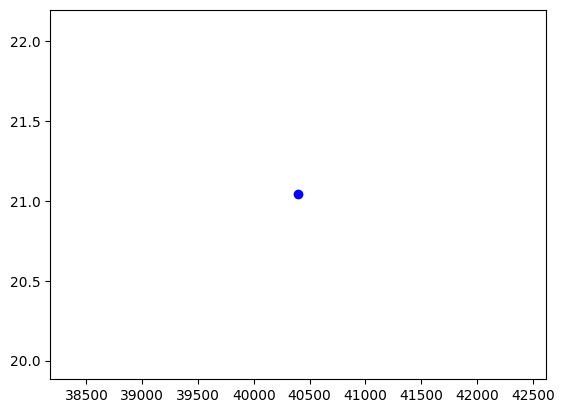

In [7]:
import matplotlib.pyplot as plt
avg_reward_full = np.mean([np.mean(ep["rewards"]) for ep in episodes if not ep["terminated_early"]])
avg_reward_early = np.mean([np.mean(ep["rewards"]) for ep in episodes if ep["terminated_early"]])

print(f"Average reward (full episode): {avg_reward_full}")
print(f"Average reward (early termination): {avg_reward_early}")

for ep in episodes:
    ep_len = ep["episode_length"]
    z0 = float(ep["z_history"][0]) if ep["z_history"].size else np.nan
    if ep_len < MAX_STEPS:
        plt.scatter(ep_len, z0, c="red")
    else:
        plt.scatter(ep_len, z0, c="blue")

plt.show()

In [84]:
def evaluate_run(episode, ma_height_len=100, ma_action_len=100, ma_reward_len=100):
    actions = episode["actions"]
    rewards = episode["rewards"]
    z_history = episode["z_history"]
    dz_history = episode["dz_history"]
    generated_image = episode.get("generated_image")

    if generated_image is not None:
        plt.rcParams["figure.figsize"] = (12, 10)
        plt.imshow(generated_image.T)
        plt.colorbar()
        plt.title("Captured image")
        plt.show()

    n_steps = len(rewards)
    max_pixels = 201 * 201

    height_img = np.full(max_pixels, np.nan, dtype=np.float32)
    n_fill = min(n_steps, max_pixels)
    height_values = z_history[:n_fill] + dz_history[:n_fill]
    height_img[:n_fill] = height_values

    height_img = height_img.reshape((201, 201))
    height_img[1::2] = height_img[1::2, ::-1]
    plt.imshow(height_img)
    plt.title("Height of tip")
    plt.colorbar()
    plt.show()

    plt.rcParams["figure.figsize"] = (20, 10)
    moving_avg = np.convolve(height_values.flatten(), np.ones(ma_height_len)/ma_height_len, mode='valid')
    plt.plot(moving_avg)
    plt.title(f"Moving average ({ma_height_len}) of height")
    plt.show()

    plt.rcParams["figure.figsize"] = (20, 10)
    moving_avg = np.convolve(np.array(actions).flatten(), np.ones(ma_action_len)/ma_action_len, mode='valid')
    plt.plot(moving_avg)
    plt.title(f"Moving average ({ma_action_len}) of actions")
    plt.show()

    plt.rcParams["figure.figsize"] = (20, 10)
    moving_avg = np.convolve(np.array(rewards).flatten(), np.ones(ma_reward_len)/ma_reward_len, mode='valid')
    plt.plot(moving_avg)
    plt.title(f"Moving average ({ma_reward_len}) of rewards (AVG={np.mean(rewards):.2f}, STD={np.std(rewards):.2f}, TOTAL={np.sum(rewards):.2f})")


In [85]:
max_len = 0
max_id = 0
for i, ep in enumerate(episodes):
    if ep["episode_length"] > max_len:
        max_len = ep["episode_length"]
        max_id = i

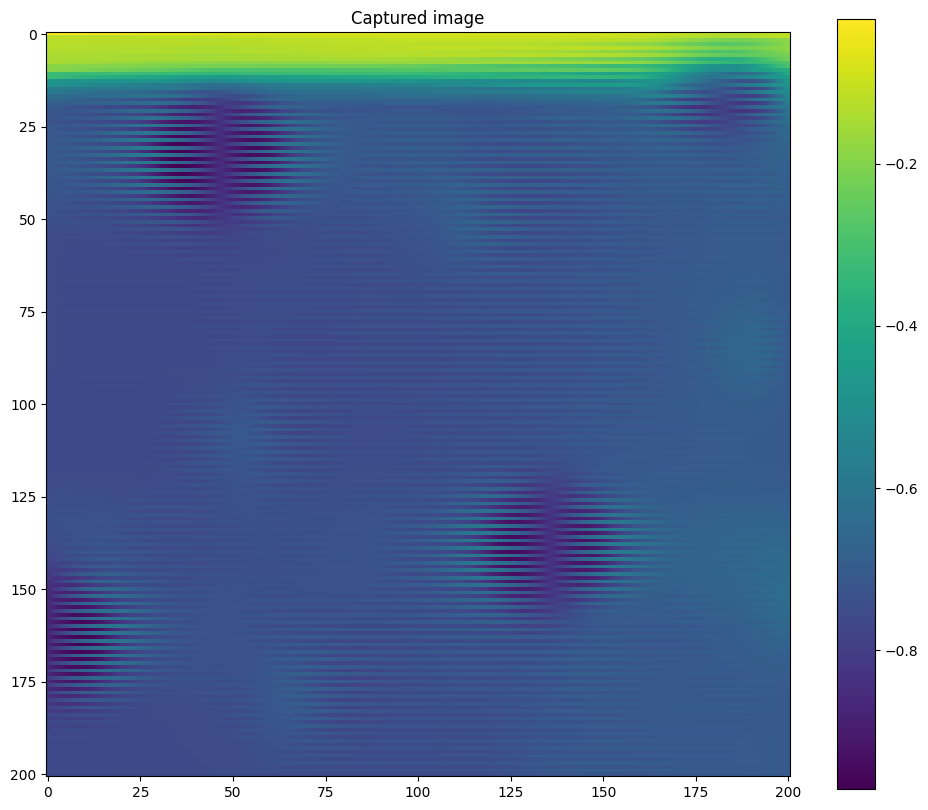

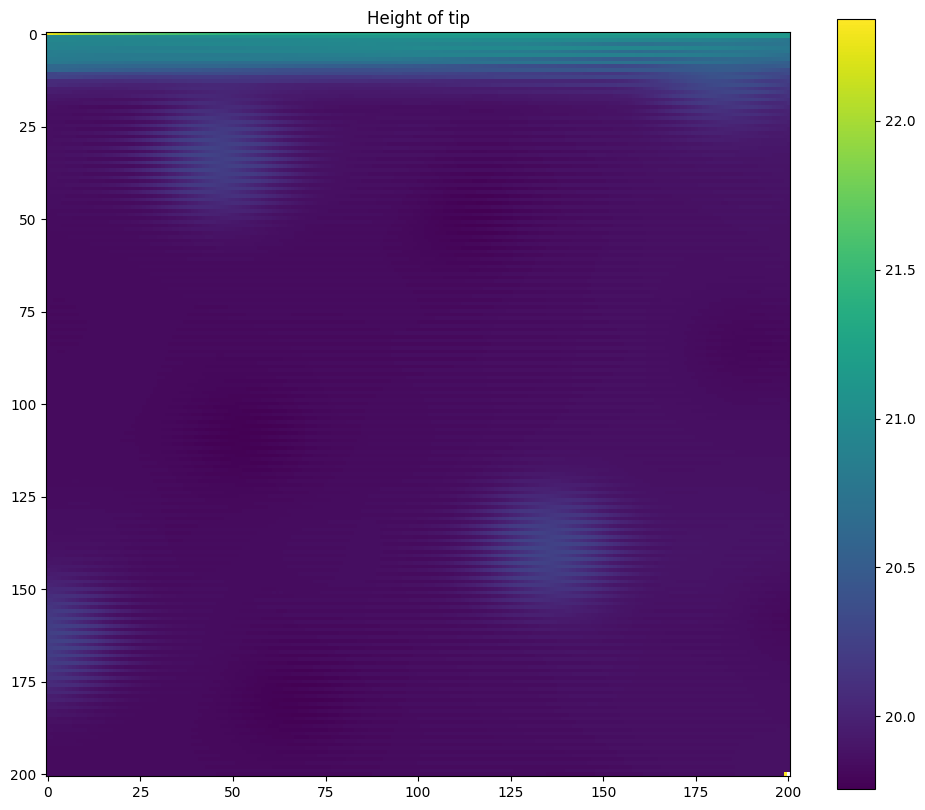

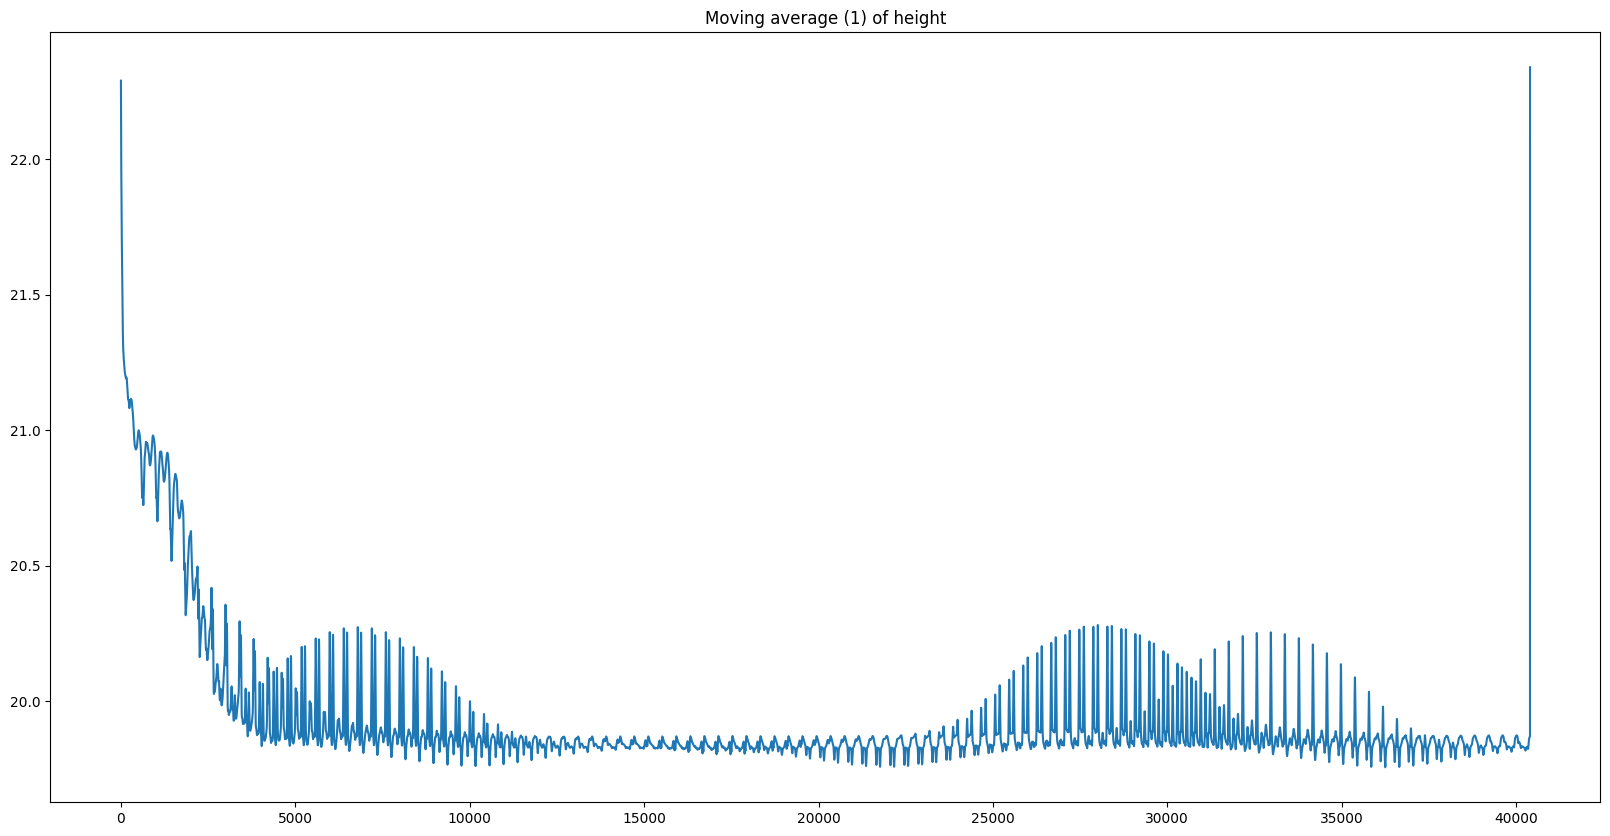

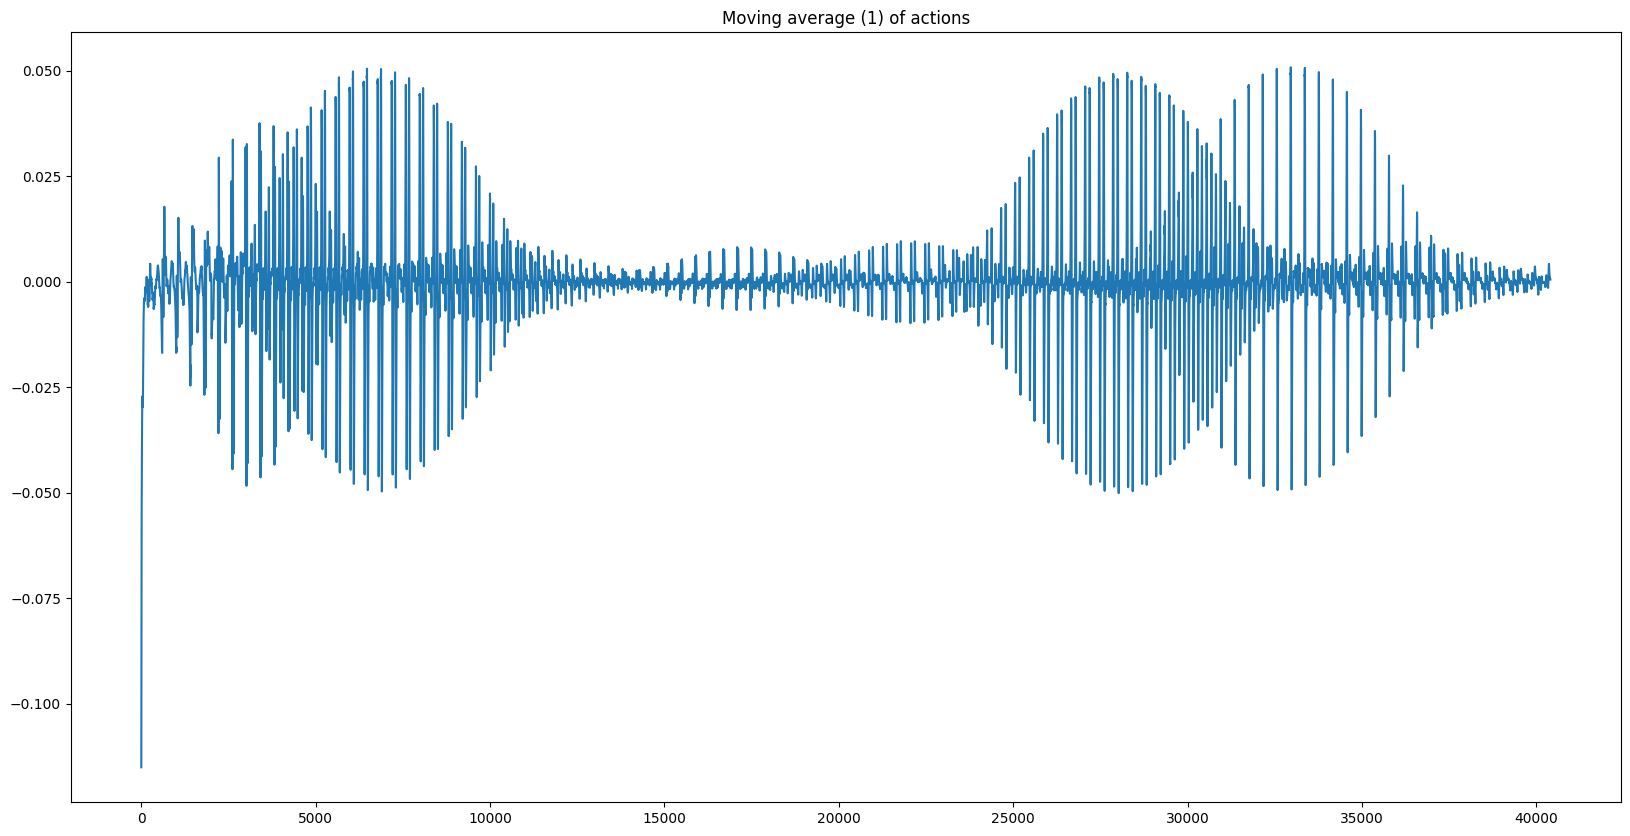

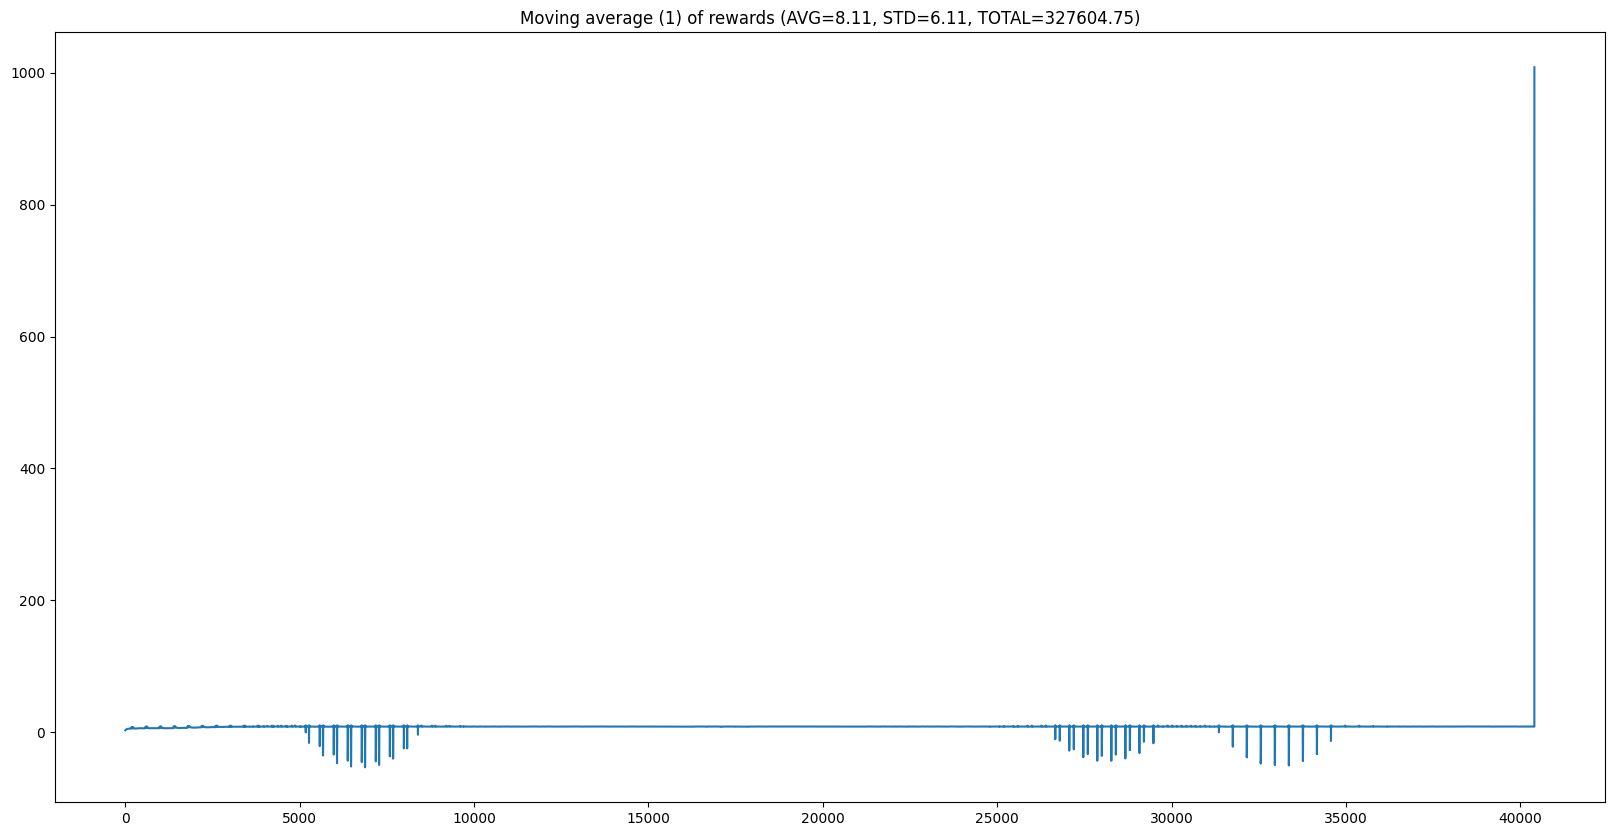

In [86]:
evaluate_run(episodes[max_id], ma_height_len=1, ma_action_len=1, ma_reward_len=1)

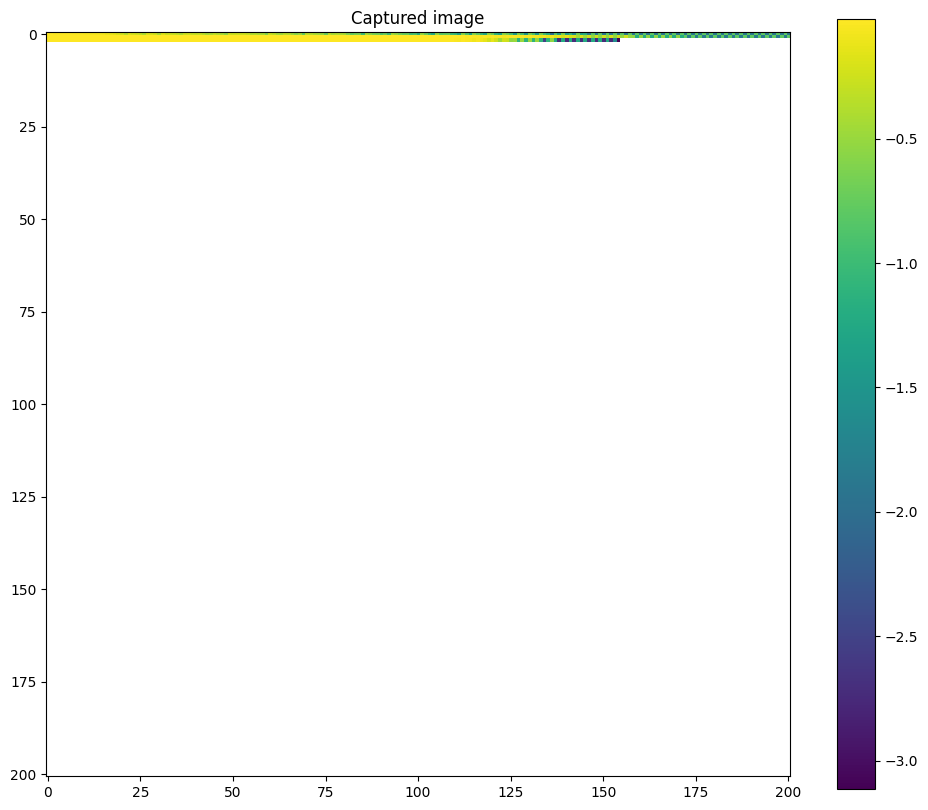

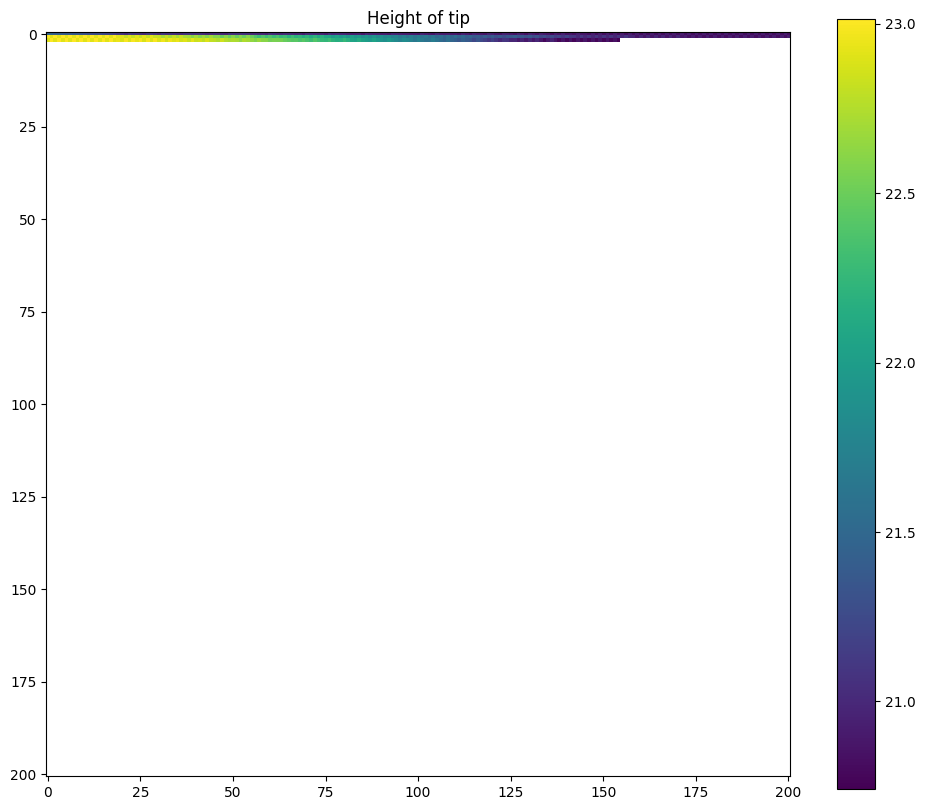

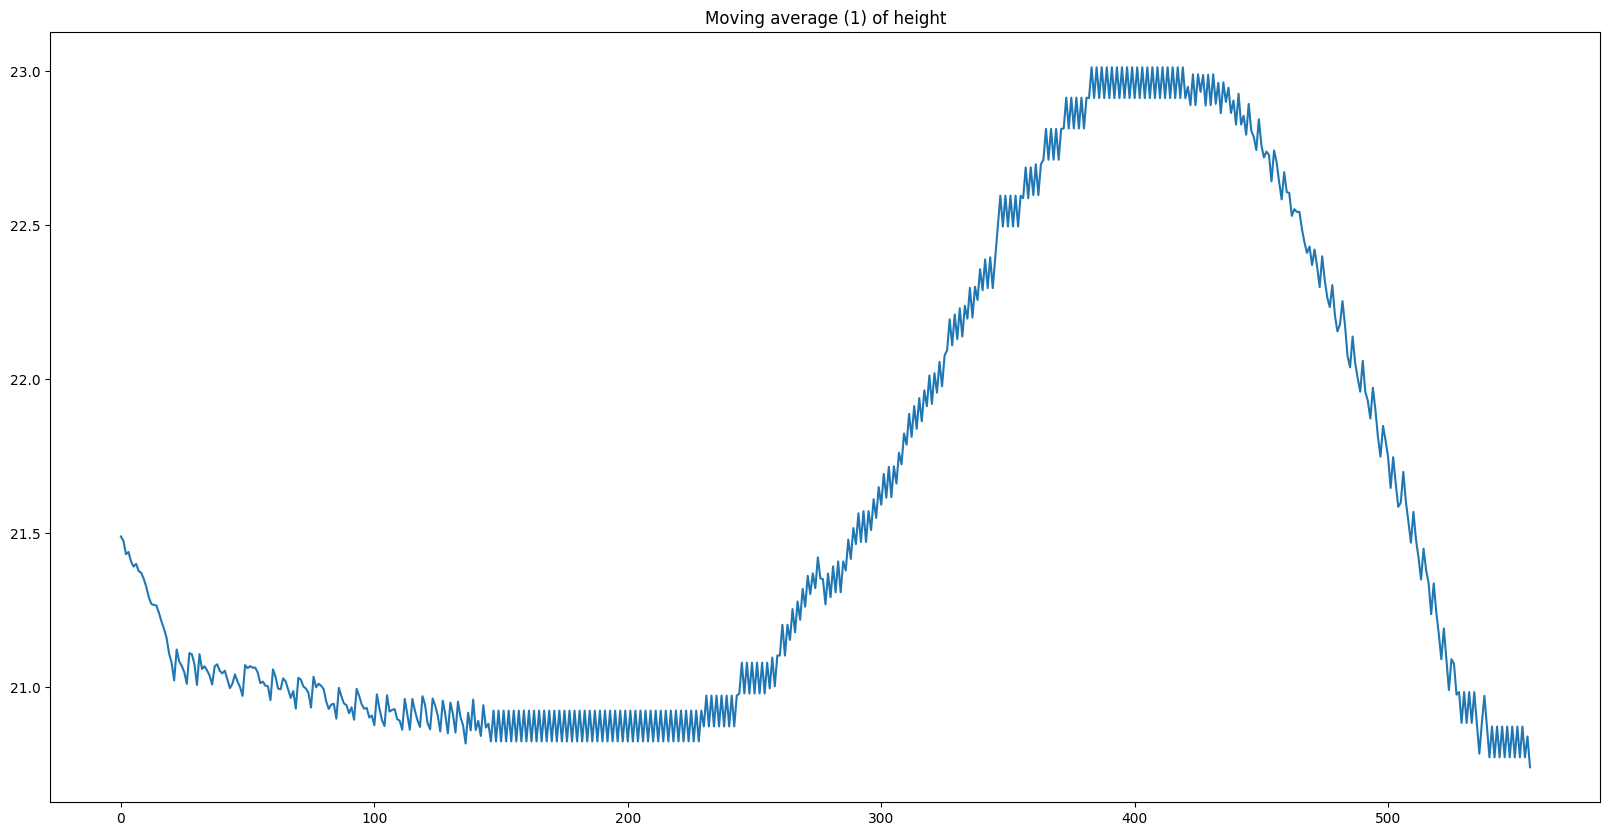

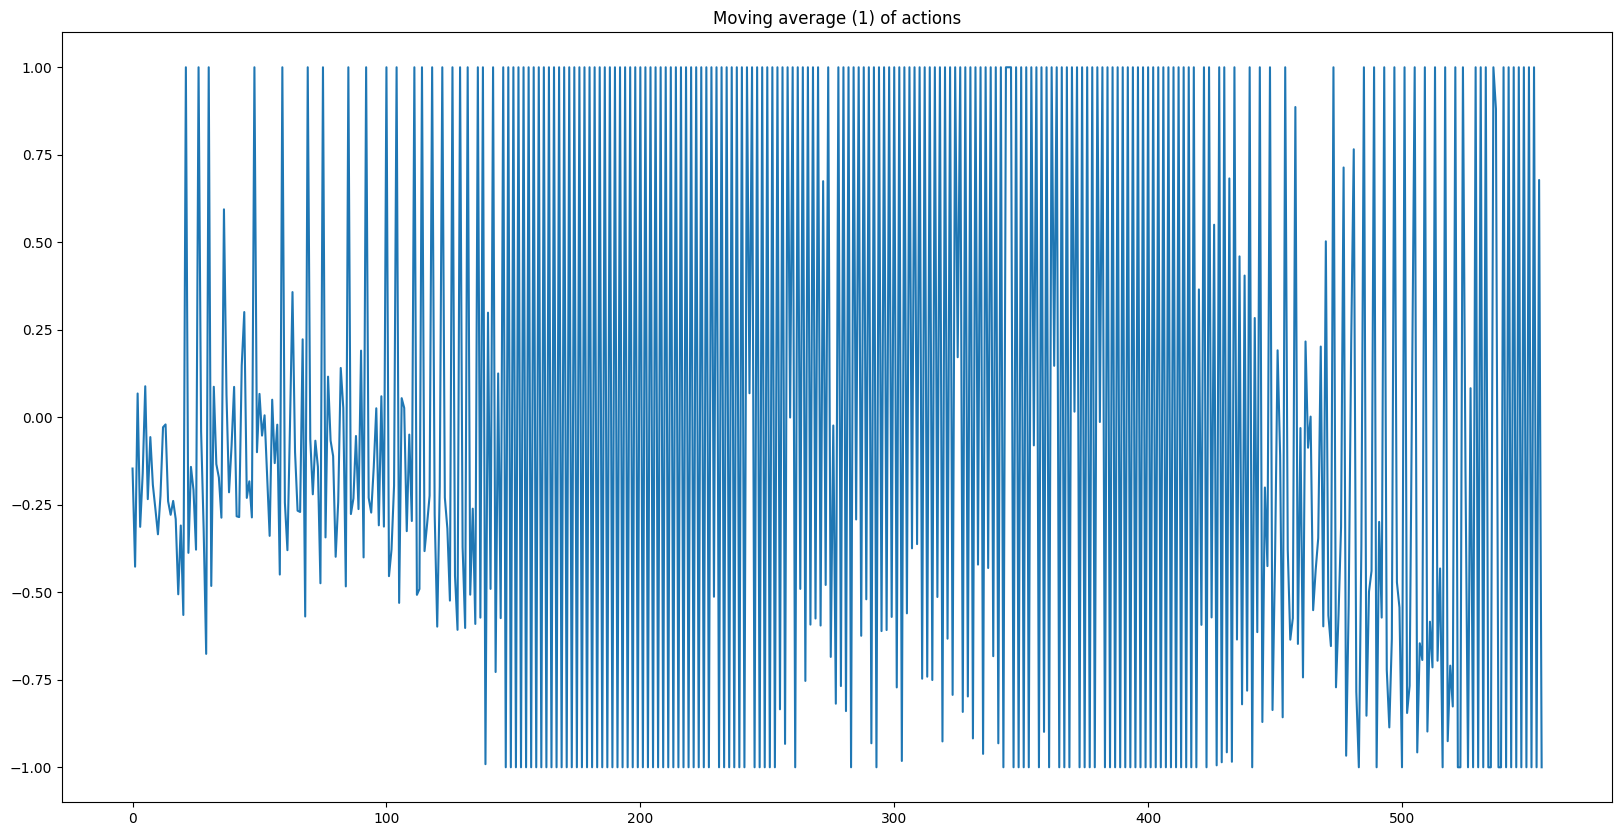

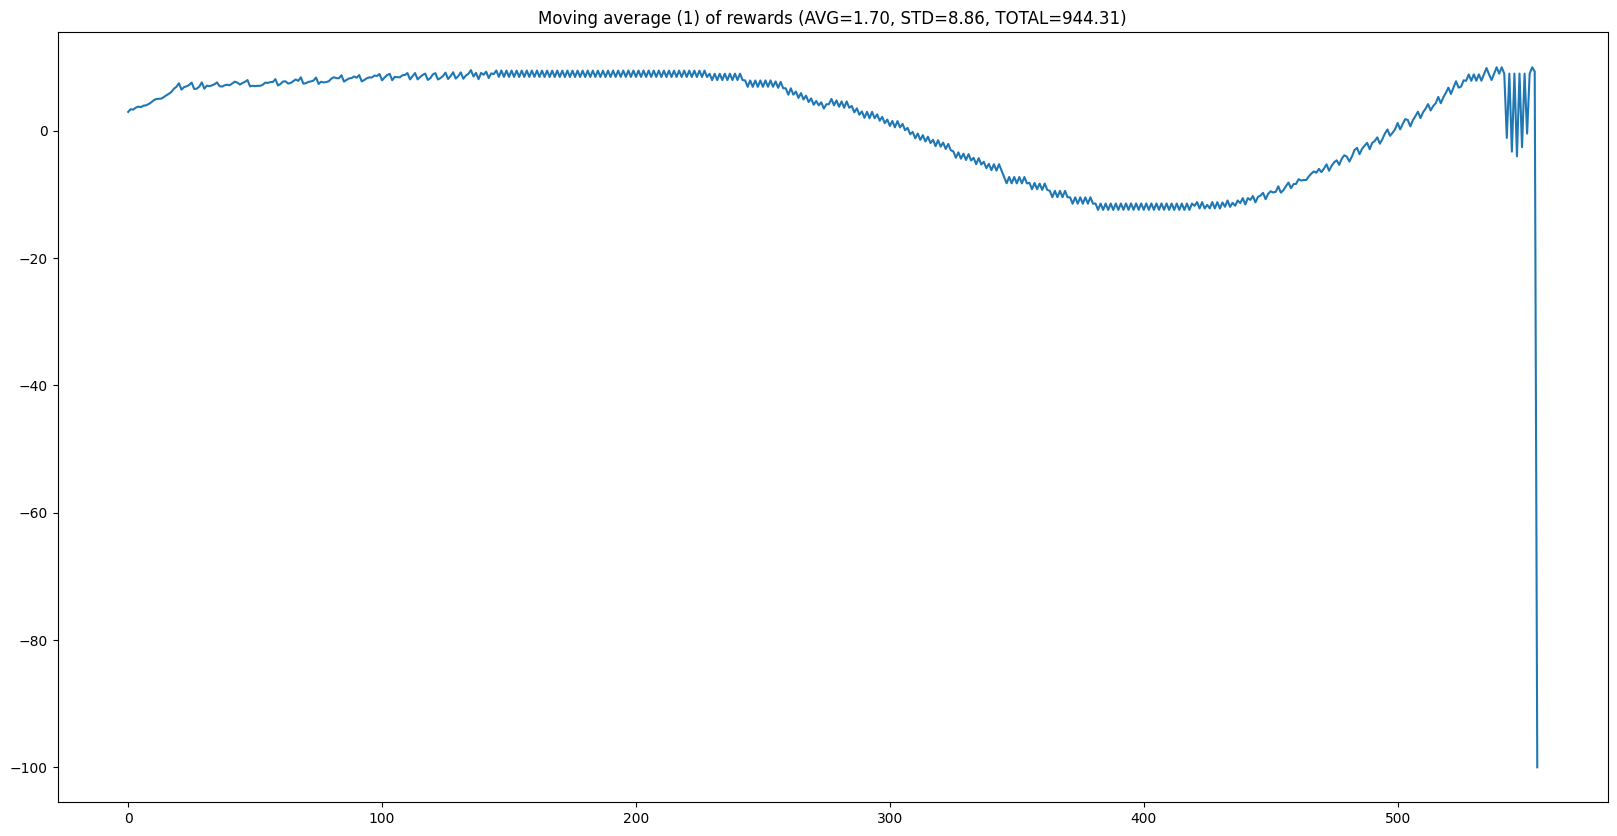

In [16]:
evaluate_run(episodes[0], ma_height_len=1, ma_action_len=1, ma_reward_len=1)